#Testbench Setup -> Generate ocean script "ocean_script_NMOS4.txt" -> Export transpose reults in .csv  
Save no result, no netlist, just need the export to generate a .csv file, run in Ocean script => No Interface lag  
See ocean_script_NMOS4.txt for exemple of ocean script used for generation  
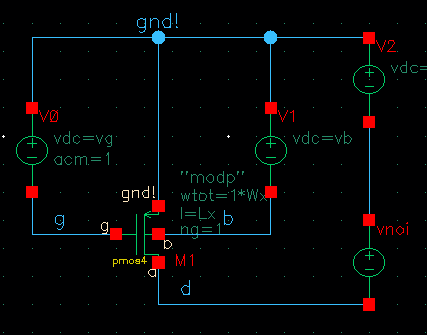 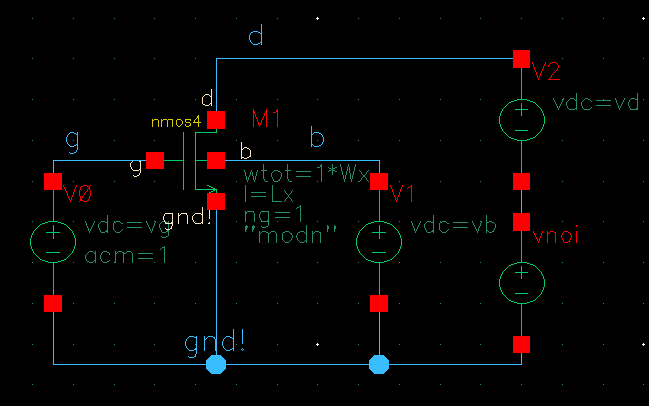 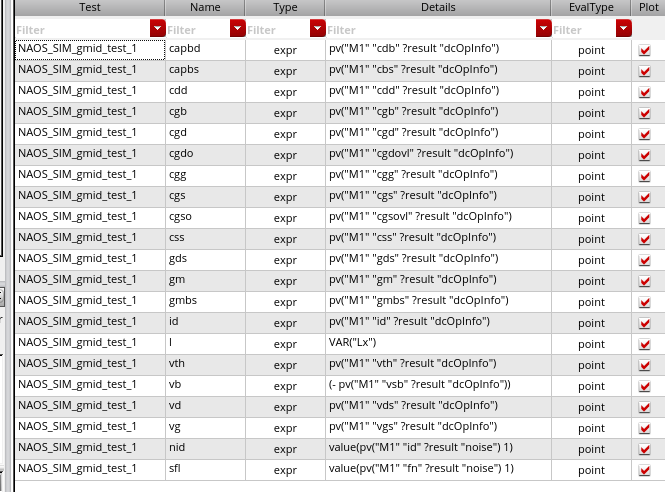


In [5]:
import pandas as pd
#from numpy.core.records import fromarrays
from numpy.rec import fromarrays  # Updated to use the public API
from scipy.io import savemat
from csv_to_mat import convert_csv_to_mat
from pygmid import Lookup as lk
import numpy as np
import scipy.constants as sc
import matplotlib.pyplot as plt
from pygmid import Lookup as lk

In [6]:
###########Input param pour .MAT
device = 'nmos_T40N'
w = 1.0
nfing = 1
txt_path = '../lookup_table/040/nmos_t40.txt'
infomos = 'T040 NMOS NCH 40nM'
#################################
#################################
#################################
#################################
###Carefull it overwrite !!!
#################################
#################################
#################################
#################################
mat_pathout, input_table = convert_csv_to_mat(device, w, nfing, txt_path, infomos)

l vb vd vg
Shape is :  (22, 3, 23, 23)
TXT to MAT DONE


In [7]:
fet = lk(mat_pathout)
# sweep variable vectors
l = fet['L']
vgs = fet['VGS']
vds = fet['VDS']
vsb = fet['VSB']

for name in ['L','VGS','VDS','VSB']:
    arr = fet[name]
    print(f"{name}: min={arr.min()} max={arr.max()}")

fet.lookup('ID', L=0.18, VDS=0.9, VGS=0.9, VSB=0)
fet['INFO']

input_table

L: min=0.04 max=10.0
VGS: min=0.0 max=1.1
VDS: min=0.0 max=1.1
VSB: min=-0.2 max=-0.0


,capbd,capbs,cdd,cgb,cgd,cgdo,cgg,cgs,cgso,css,...,gm,gmbs,id,l,nid,n1overf,vb,vd,vg,vth
0,1.439000e-19,1.599000e-18,2.154000e-16,6.570000e-17,2.095000e-16,4.309000e-18,4.771000e-16,2.019000e-16,3.336000e-18,2.096000e-16,...,0.000000,0.000000,0.000000e+00,4.000000e-08,1.042000e-29,0.000000e+00,0.0,0.0,0.00,0.6292
1,1.747000e-19,1.830000e-18,2.186000e-16,6.332000e-17,2.110000e-16,5.584000e-18,4.751000e-16,2.008000e-16,4.669000e-18,2.110000e-16,...,0.000000,0.000000,3.359000e-16,4.000000e-08,3.683000e-29,0.000000e+00,0.0,0.0,0.05,0.6292
2,2.191000e-19,1.985000e-18,2.224000e-16,6.120000e-17,2.128000e-16,7.160000e-18,4.732000e-16,1.993000e-16,6.352000e-18,2.127000e-16,...,0.000000,0.000000,8.973000e-16,4.000000e-08,1.264000e-28,0.000000e+00,0.0,0.0,0.10,0.6292
3,2.951000e-19,2.042000e-18,2.273000e-16,5.928000e-17,2.149000e-16,9.200000e-18,4.715000e-16,1.973000e-16,8.421000e-18,2.149000e-16,...,0.000000,0.000000,3.246000e-15,4.000000e-08,4.324000e-28,0.000000e+00,0.0,0.0,0.15,0.6292
4,4.433000e-19,2.033000e-18,2.341000e-16,5.749000e-17,2.179000e-16,1.207000e-17,4.703000e-16,1.950000e-16,1.086000e-17,2.183000e-16,...,0.000000,0.000000,7.716000e-15,4.000000e-08,1.471000e-27,0.000000e+00,0.0,0.0,0.20,0.6292
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34909,1.508000e-17,3.238000e-15,3.221000e-16,5.073000e-16,2.539000e-16,4.979000e-17,8.904000e-14,8.930000e-14,8.909000e-14,8.602000e-14,...,0.000017,0.000002,4.702000e-06,1.000000e-05,6.073000e-29,3.626000e-21,0.2,1.1,0.90,0.3598
34910,1.630000e-17,3.477000e-15,3.473000e-16,7.636000e-16,2.649000e-16,6.050000e-17,8.942000e-14,8.992000e-14,8.971000e-14,8.640000e-14,...,0.000018,0.000002,5.559000e-06,1.000000e-05,8.087000e-29,4.509000e-21,0.2,1.1,0.95,0.3598
34911,1.756000e-17,3.711000e-15,3.776000e-16,1.013000e-15,2.781000e-16,7.338000e-17,8.976000e-14,9.049000e-14,9.029000e-14,8.675000e-14,...,0.000019,0.000002,6.474000e-06,1.000000e-05,1.065000e-28,5.472000e-21,0.2,1.1,1.00,0.3598
34912,1.885000e-17,3.939000e-15,4.140000e-16,1.257000e-15,2.939000e-16,8.892000e-17,9.006000e-14,9.102000e-14,9.082000e-14,8.705000e-14,...,0.000020,0.000003,7.440000e-06,1.000000e-05,1.391000e-28,6.495000e-21,0.2,1.1,1.05,0.3598


In [8]:
# sweep variable vectors
l = fet['L']
vgs = fet['VGS']
vds = fet['VDS']
vsb = fet['VSB']

for name in ['L','VGS','VDS','VSB']:
    arr = fet[name]
    print(f"{name}: min={arr.min()} max={arr.max()} default≈{arr[len(arr)//2]}")


L: min=0.04 max=10.0 default≈0.5
VGS: min=0.0 max=1.1 default≈0.55
VDS: min=0.0 max=1.1 default≈0.55
VSB: min=-0.2 max=-0.0 default≈-0.1


In [9]:
fet.lookup('CGG_W', L=0.18, VDS=0.9, VGS=0.9, VSB=0)

array(3.2668621e-15)

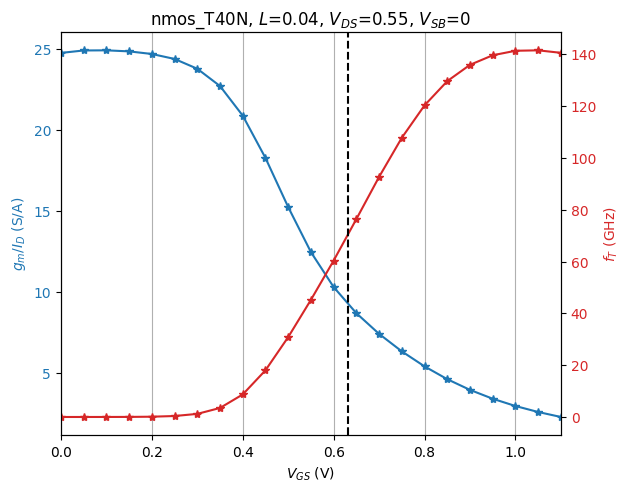

In [10]:
# plot gm/ID and fT versus gate bias
L1 = min(l); VDS1=0.55; VSB1=0
gm_id1 = fet.lookup('GM_ID', L=L1, VDS=VDS1, VSB=VSB1)
ft1 = fet.lookup('GM_CGG', L=L1, VDS=VDS1, VSB=VSB1)/2/np.pi
vt = fet.lookup('VT', L=L1, VGS=0.9, VDS=VDS1, VSB=VSB1)

fig, ax1 = plt.subplots()
ax1.grid(axis='x')
ax1.set_xlabel('$V_{GS}$ (V)')
color = 'tab:blue'
ax1.set_ylabel('$g_m/I_D$ (S/A)', color=color)
ax1.plot(vgs, gm_id1, color=color, marker='*')
ax1.tick_params(axis='y', labelcolor=color)
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('$f_T$ (GHz)', color=color)
ax2.plot(vgs, ft1/1e9, color=color, marker='*')
ax2.tick_params(axis='y', labelcolor=color)
fig.tight_layout()
plt.title(device+', $L$='+str(L1)+', $V_{DS}$='+str(VDS1)+', $V_{SB}$='+str(VSB1))
plt.xlim(0, vgs[-1])
plt.axvline(x=vt, color='k', linestyle='--')
plt.show()

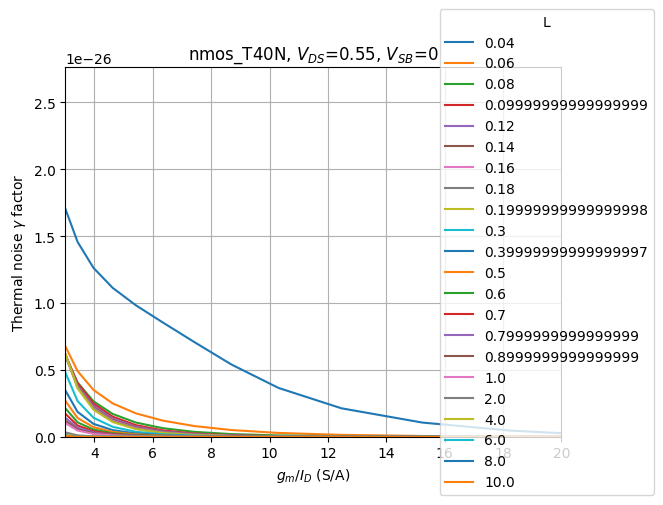

In [15]:
# plot gamma versus gm/ID for all L
gamma = fet.lookup('STH_GM', L=l, VDS=VDS1, VSB=VSB1) / (4*sc.Boltzmann*300)

fig, ax = plt.subplots()
ax.plot(gm_id1.transpose(), gamma.transpose())
ax.legend(loc='center right', bbox_to_anchor=(1.2, 0.5), title='L', labels=l.tolist())
plt.xlim(3, 20)
plt.ylim(0, )
plt.xlabel('$g_m/I_D$ (S/A)')
plt.ylabel(r'Thermal noise $\gamma$ factor')
plt.grid(which='minor')
plt.grid(which='major')
plt.title(device+', $V_{DS}$='+str(VDS1)+', $V_{SB}$='+str(VSB1))
plt.show()